In [99]:
import pandas as pd
import numpy as np
import requests

import warnings
warnings.filterwarnings("ignore")

In [100]:
requests.get("https://www.ambitionbox.com/list-of-companies").text

'<HTML><HEAD>\n<TITLE>Access Denied</TITLE>\n</HEAD><BODY>\n<H1>Access Denied</H1>\n \nYou don\'t have permission to access "http&#58;&#47;&#47;www&#46;ambitionbox&#46;com&#47;list&#45;of&#45;companies" on this server.<P>\nReference&#32;&#35;18&#46;c7f5d217&#46;1779379103&#46;4b7070bc\n<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;c7f5d217&#46;1779379103&#46;4b7070bc</P>\n</BODY>\n</HTML>\n'

In [101]:
url = "https://www.ambitionbox.com/list-of-companies?page-1"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36"
}

In [102]:
response = requests.get(url=url, headers=headers).text

'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <link rel="manifest" href="/assets/next/manifest.json">\n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script src="/static/js/env-runtime.js" defer></script>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>\n    <title>Top Companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name="revisit-after" content="1 day"><meta dat
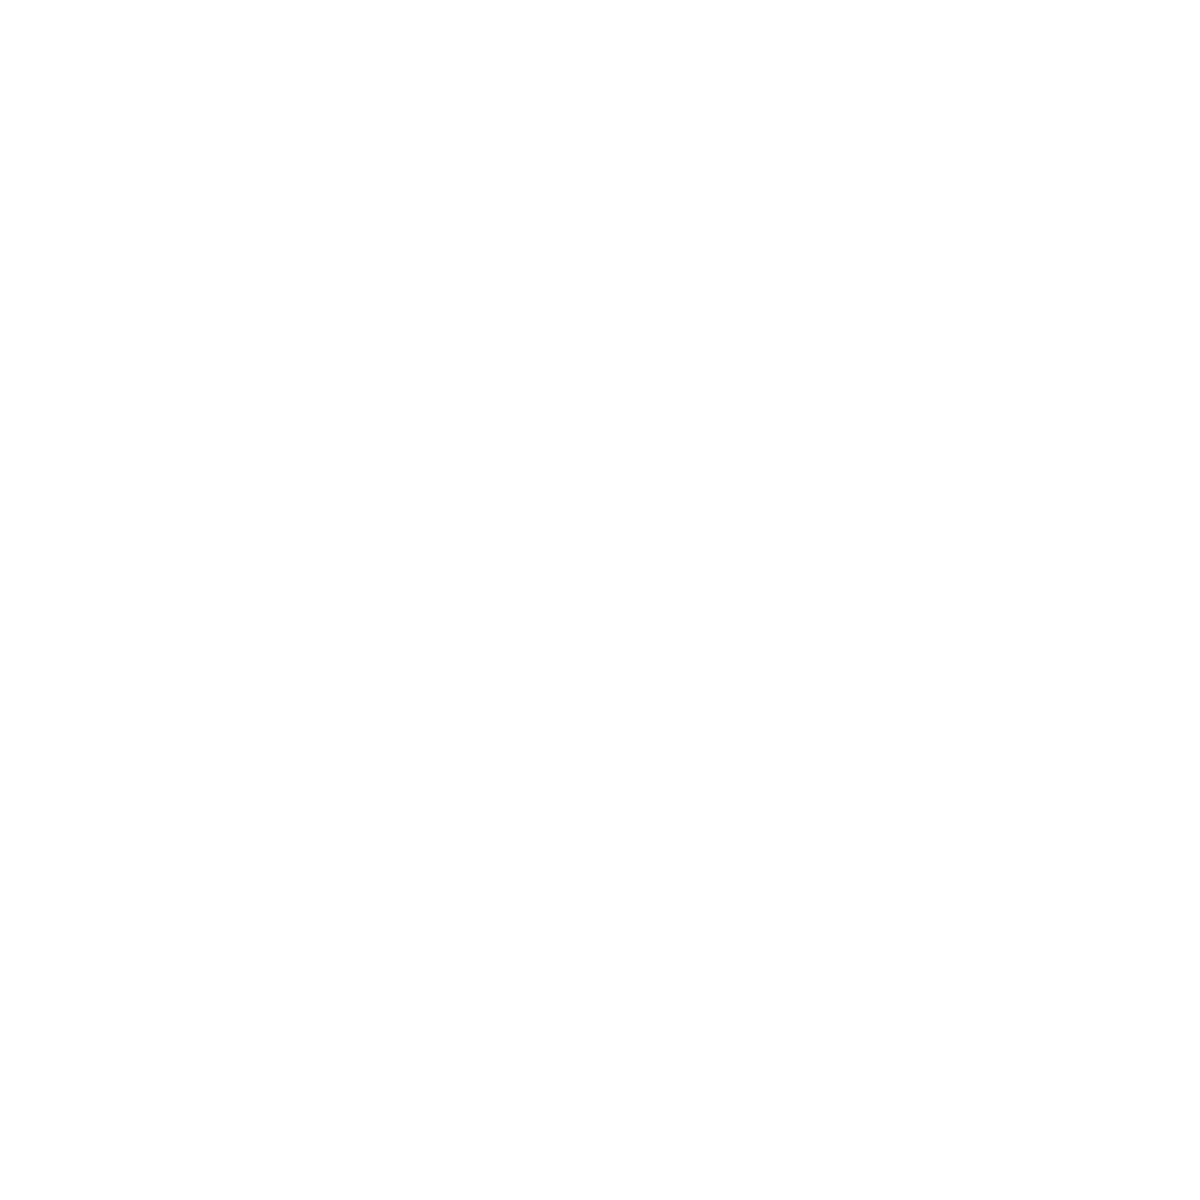

In [103]:
response

In [104]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response, 'lxml')

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<link href="/assets/next/manifest.json" rel="manifest"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script defer="" src="/static/js/env-runtime.js"></script>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
<title>Top Companies in India | AmbitionBox</title><meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta content="AmbitionBox" data-n-head="ssr" nam
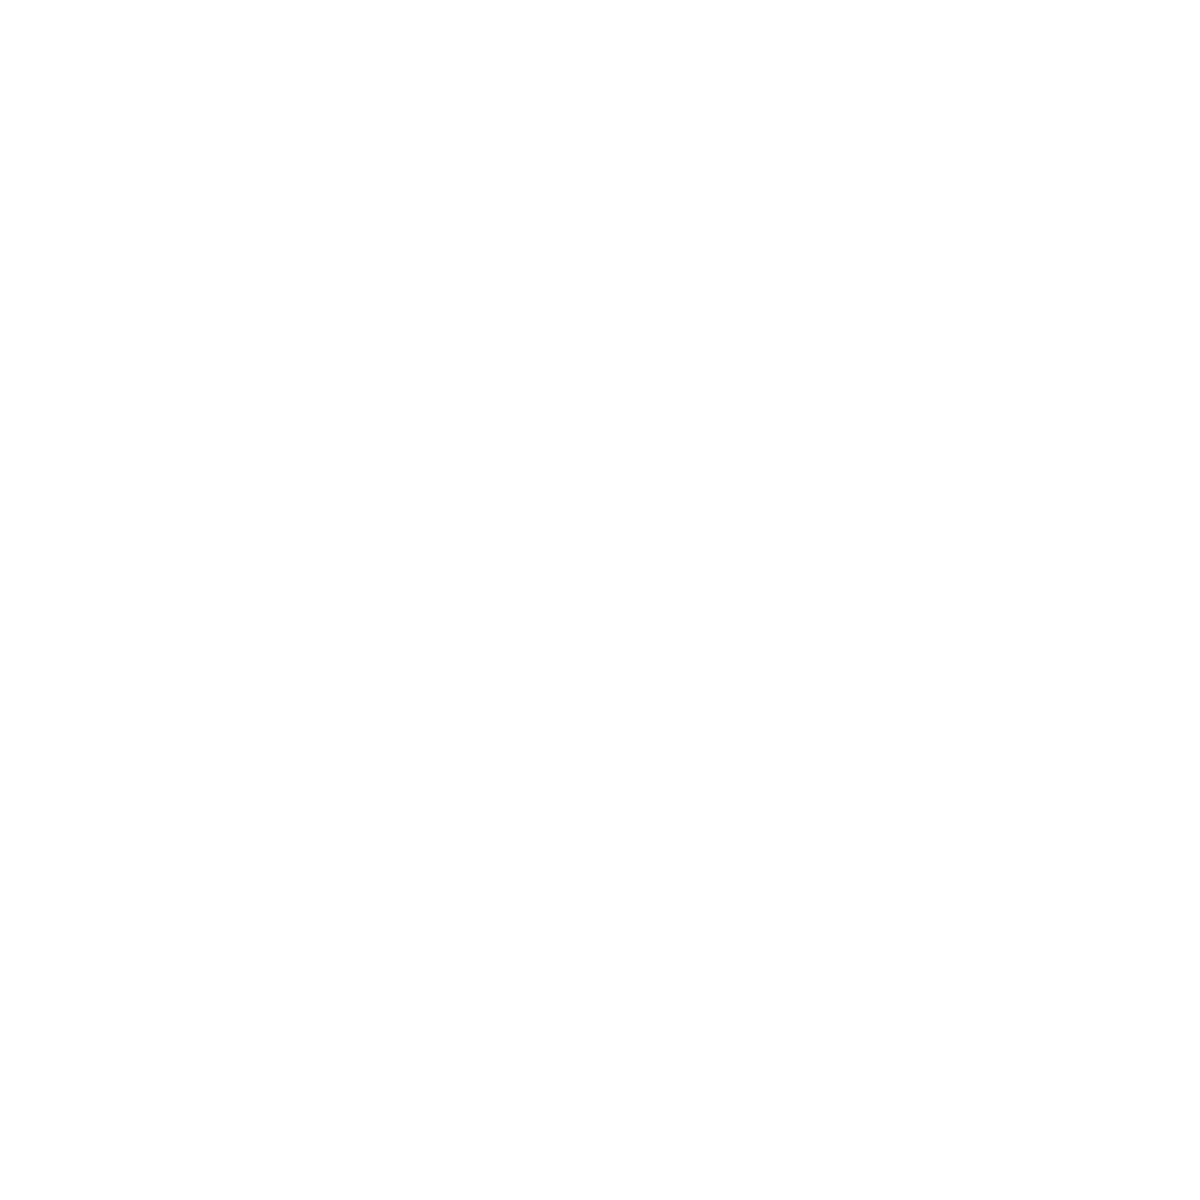

In [105]:
soup

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
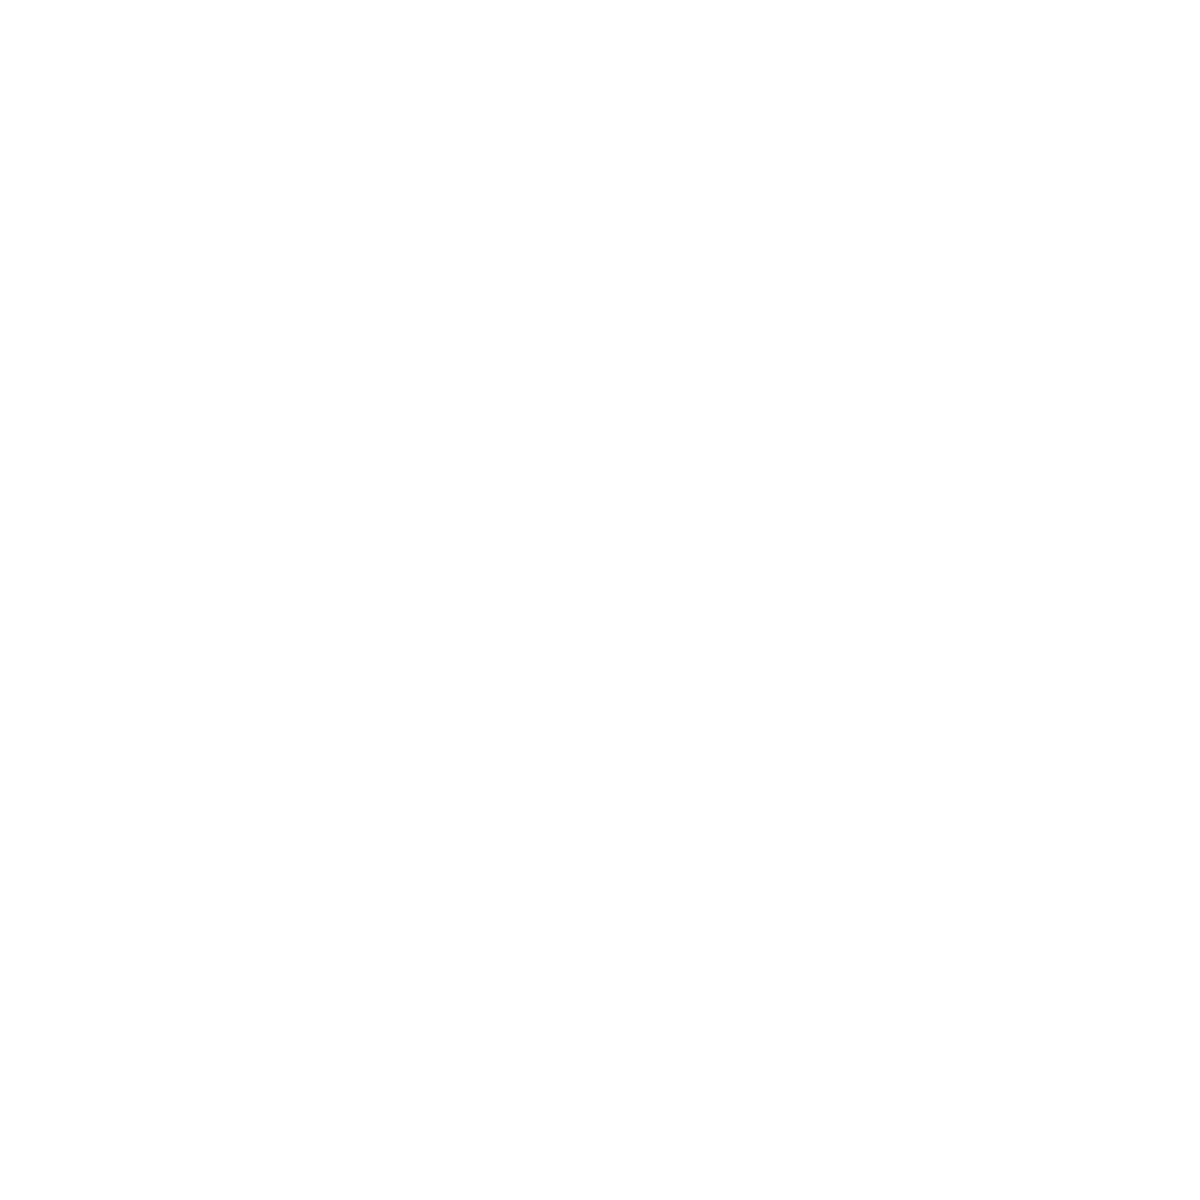

In [106]:
print(soup.prettify())

In [107]:
soup.find_all('h2')[:6]

[<h2 class="companyListing__title">
 								Companies in India
 							</h2>,
 <h2 class="companyCardWrapper__companyName" title="TCS">
 									TCS
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Accenture">
 									Accenture
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Wipro">
 									Wipro
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cognizant">
 									Cognizant
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Capgemini">
 									Capgemini
 								</h2>]

In [108]:
for h2_tag in soup.find_all('h2')[:6]:
    print(h2_tag.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini


<h1>Scrapping companies:</h1>

- I can observe that there is similare cards on the website page that we have extracted in response
- stored in the div with class="companyCardWrapper__metaInformation"

In [128]:
cards = soup.find_all('div', class_ ="companyCardWrapper__metaInformation")

In [129]:
cards[0]

<div class="companyCardWrapper__metaInformation"><div class="companyCardWrapper__header"><div class="companyCardWrapper__companyPrimaryDetailsTopSection"><a class="companyCardWrapper__companyName"><h2 class="companyCardWrapper__companyName" title="TCS">
									TCS
								</h2></a> <!-- --></div> <button arialabel="Follow" class="companyCardWrapper__FollowCTA g-btn g-btn--text g-btn--md" data-testid="" title="Follow" type="button"><!-- --> <span class="g-btn__label g-btn__label--md g-btn__label--text g-btn__label--loader">Follow</span> <!-- --> <!-- --></button> <!-- --></div> <div class="companyCardWrapper__ratingWrapper"><div class="companyCardWrapper__companyRatingWrapper"><div class="companyCardWrapper__companyRating"><div class="rating_star_container" style="line-height:20px;"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#FFBA01" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18

In [130]:
# company names are there in h2 tag with class="companyCardWrapper__companyName"

<h2>Company name scraping:</h2>

In [131]:
total_companies = len(cards)
print(total_companies)

20


In [132]:
cards[0].find_all('h2', class_="companyCardWrapper__companyName")


[<h2 class="companyCardWrapper__companyName" title="TCS">
 									TCS
 								</h2>]

In [133]:
cards[0].find_all('h2', class_="companyCardWrapper__companyName")[0]

<h2 class="companyCardWrapper__companyName" title="TCS">
									TCS
								</h2>

In [134]:
cards[0].find_all('h2', class_="companyCardWrapper__companyName")[0].text

'\n\t\t\t\t\t\t\t\t\tTCS\n\t\t\t\t\t\t\t\t'

In [135]:
cards[0].find_all('h2', class_="companyCardWrapper__companyName")[0].text.strip()

'TCS'

<h2>Company ratings scraping:</h2>

In [136]:
# Ratings are there in div with class = "rating_text rating_text--md"

In [137]:
cards[0].find_all("div", class_ = "rating_text rating_text--md")

[<div class="rating_text rating_text--md"><div style="height:auto;">
 			3.3<!-- --></div></div>]

In [138]:
cards[0].find_all("div", class_ = "rating_text rating_text--md")[0]

<div class="rating_text rating_text--md"><div style="height:auto;">
			3.3<!-- --></div></div>

In [139]:
cards[0].find_all("div", class_ = "rating_text rating_text--md")[0].text


'\n\t\t\t3.3'

In [140]:
cards[0].find_all("div", class_ = "rating_text rating_text--md")[0].text.strip()

'3.3'

<h2>Company ratings count scraping:</h2>

In [144]:
# span with class="companyCardWrapper__companyRatingCount"

In [145]:
cards[0].find_all("span", class_="companyCardWrapper__companyRatingCount")

[<span class="companyCardWrapper__companyRatingCount">
 								(1.1L)
 							</span>]

In [146]:
cards[0].find_all("span", class_="companyCardWrapper__companyRatingCount")[0]

<span class="companyCardWrapper__companyRatingCount">
								(1.1L)
							</span>

In [147]:
cards[0].find_all("span", class_="companyCardWrapper__companyRatingCount")[0].text

'\n\t\t\t\t\t\t\t\t(1.1L)\n\t\t\t\t\t\t\t'

In [150]:
cards[0].find_all("span", class_="companyCardWrapper__companyRatingCount")[0].text.strip()

'(1.1L)'

<h2>About Company:</h2>

In [154]:
# span with class="companyCardWrapper__interLinking"

In [155]:
cards[0].find_all('span', class_="companyCardWrapper__interLinking")

[<span class="companyCardWrapper__interLinking">
 							IT Services &amp; Consulting | Bengaluru +444 other locations
 						</span>]

In [156]:
cards[0].find_all('span', class_="companyCardWrapper__interLinking")[0]

<span class="companyCardWrapper__interLinking">
							IT Services &amp; Consulting | Bengaluru +444 other locations
						</span>

In [157]:
cards[0].find_all('span', class_="companyCardWrapper__interLinking")[0].text

'\n\t\t\t\t\t\t\tIT Services & Consulting | Bengaluru +444 other locations\n\t\t\t\t\t\t'

In [158]:
cards[0].find_all('span', class_="companyCardWrapper__interLinking")[0].text.strip()

'IT Services & Consulting | Bengaluru +444 other locations'

<h2>Second card:</h2>

- Second card consists of Reviews, Salaries, Interviews, Jobs, Benefits, Photos
- in div tag with class="companyCardWrapper__tertiaryInformation"

In [159]:
cards2 = soup.find_all('div', class_ = "companyCardWrapper__tertiaryInformation")

In [161]:
cards2[0]

<div class="companyCardWrapper__tertiaryInformation"><a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/reviews/tcs-reviews" target="_blank"><span class="companyCardWrapper__ActionCount">1.1L</span> <span class="companyCardWrapper__ActionTitle">Reviews</span></a><a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/salaries/tcs-salaries" target="_blank"><span class="companyCardWrapper__ActionCount">10.2L</span> <span class="companyCardWrapper__ActionTitle">Salaries</span></a><a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/interviews/tcs-interview-questions" target="_blank"><span class="companyCardWrapper__ActionCount">11.9k</span> <span class="companyCardWrapper__ActionTitle">Interviews</span></a><a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/jobs/tcs-jobs-cmp" target="_blank"><span class="companyCardWrapper__ActionCount">4.5k</span> <span class="companyCardWrapper__Actio

## Number of reviews
- span with class="companyCardWrapper__ActionCount"

In [164]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")

[<span class="companyCardWrapper__ActionCount">1.1L</span>,
 <span class="companyCardWrapper__ActionCount">10.2L</span>,
 <span class="companyCardWrapper__ActionCount">11.9k</span>,
 <span class="companyCardWrapper__ActionCount">4.5k</span>,
 <span class="companyCardWrapper__ActionCount">10.7k</span>,
 <span class="companyCardWrapper__ActionCount">93</span>]

1. No. of Reviews
2. Salaries
3. Interviews
4. Jobs
5. Benefits
6. Photos

In [166]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[0].text

'1.1L'

In [167]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[1].text

'10.2L'

In [168]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[2].text

'11.9k'

In [169]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[3].text

'4.5k'

In [170]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[4].text

'10.7k'

In [171]:
cards2[0].find_all('span', class_ = "companyCardWrapper__ActionCount")[5].text

'93'

In [174]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[0].find_all('span')

[<span class="companyCardWrapper__ActionCount">1.1L</span>,
 <span class="companyCardWrapper__ActionTitle">Reviews</span>]

In [175]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[1].find_all('span')

[<span class="companyCardWrapper__ActionCount">10.2L</span>,
 <span class="companyCardWrapper__ActionTitle">Salaries</span>]

In [176]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[2].find_all('span')

[<span class="companyCardWrapper__ActionCount">11.9k</span>,
 <span class="companyCardWrapper__ActionTitle">Interviews</span>]

In [177]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[3].find_all('span')

[<span class="companyCardWrapper__ActionCount">4.5k</span>,
 <span class="companyCardWrapper__ActionTitle">Jobs</span>]

In [178]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[4].find_all('span')

[<span class="companyCardWrapper__ActionCount">10.7k</span>,
 <span class="companyCardWrapper__ActionTitle">Benefits</span>]

In [179]:
cards2[0].find_all("a", class_="companyCardWrapper__ActionWrapper")[5].find_all('span')

[<span class="companyCardWrapper__ActionCount">93</span>,
 <span class="companyCardWrapper__ActionTitle">Photos</span>]

### Creating Custom functions to scratch 

In [275]:
def scratch_company_data(soup, scratched_data, class1 = "companyCardWrapper__metaInformation", class2 = "companyCardWrapper__tertiaryInformation"):

    # from cards 1
    cards1 = soup.find_all('div', class_ = class1)

    for i in range(len(cards1)):
        # company names are there in h2 tag with class="companyCardWrapper__companyName"
        scratched_data['Company_name'].append(cards1[i].find_all('h2', class_ = "companyCardWrapper__companyName")[0].text.strip())
    
        # about company name :- span with class="companyCardWrapper__interLinking"
        scratched_data['Description'].append(cards1[i].find_all('span', class_ = "companyCardWrapper__interLinking")[0].text.strip())
    
        # Company ratings : # Ratings are there in div with class = "rating_text rating_text--md"
        scratched_data['Ratings'].append(cards1[i].find_all('div', class_ = "rating_text rating_text--md")[0].text.strip())
    
        # Rating counts : # span with class="companyCardWrapper__companyRatingCount"
        scratched_data['Rating_count'].append(cards1[i].find_all('span', class_ = "companyCardWrapper__companyRatingCount")[0].text.strip())

    #from cards2 --> at class2
    cards2 = soup.find_all('div', class_ = class2)

    # data stored :- span with class="companyCardWrapper__ActionCount"
    # 1. No. of Reviews
    # 2. Salaries
    # 3. Interviews
    # 4. Jobs
    # 5. Benefits
    # 6. Photos
    for i in range(len(cards2)):
        scratched_data["No_of_reviews"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[0].text.strip())
        scratched_data["Salaries"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[1].text.strip())
        scratched_data["Interviews"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[2].text.strip())
        scratched_data["Jobs"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[3].text.strip())
        scratched_data["Benefits"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[4].text.strip())
        scratched_data["Photos"].append(cards2[i].find_all('span', class_ = "companyCardWrapper__ActionCount")[5].text.strip())

In [276]:
scratched_data = {
    "Company_name":[], 
    "Description":[],
    "Ratings":[],
    "Rating_count":[],
    "No_of_reviews":[],
    "Salaries":[],
    "Interviews":[],
    "Jobs":[],
    "Benefits":[],
    "Photos":[]
}
scratch_company_data(soup, scratched_data)

In [277]:
for key, value in scratched_data.items():
    print(key, len(value))

Company_name 20
Description 20
Ratings 20
Rating_count 20
No_of_reviews 20
Salaries 20
Interviews 20
Jobs 20
Benefits 20
Photos 20


In [278]:
# convert dictionary of data into pandas dataframe
pd.DataFrame(scratched_data)

,Company_name,Description,Ratings,Rating_count,No_of_reviews,Salaries,Interviews,Jobs,Benefits,Photos
0,HDB Financial Services,NBFC | Mumbai +1093 other locations,3.9,(25.8k),25.8k,49k,1.1k,2.1k,1.5k,73
1,Larsen & Toubro Limited,Engineering & Construction | Chennai +771 othe...,3.9,(24k),24k,77k,1.9k,297,2.5k,65
2,Deloitte,Management Consulting | Hyderabad +182 other l...,3.7,(23.3k),23.3k,2.7L,3.4k,2k,2.4k,27
3,Kotak Mahindra Bank,Banking | Mumbai +691 other locations,3.6,(22.5k),22.5k,87.1k,1.4k,167,1.3k,45
4,Reliance Industries,Oil & Gas | Jamnagar +820 other locations,4.0,(20.3k),20.3k,74.4k,1.6k,86,1.9k,38
5,Vodafone Idea,Telecom | Pune +705 other locations,3.9,(17.6k),17.6k,49.4k,699,84,2k,22
6,Bharti Airtel,Telecom | Gurugram +792 other locations,3.8,(17.1k),17.1k,50.1k,1.1k,177,1.6k,101
7,BYJU'S,EdTech | Bengaluru +321 other locations,3.2,(16.4k),16.4k,53k,2.1k,1,1.7k,28
8,WNS,IT Services & Consulting | Pune +66 other loca...,3.3,(15.3k),15.3k,71.1k,1.3k,84,1.3k,24
9,IDFC FIRST Bank,Banking | Mumbai +731 other locations,3.9,(14.7k),14.7k,50.3k,986,43,735,96


In [279]:
# this is for page 1 only , total pages : more than 103 but i will do for 50 pages only

In [280]:
url = "https://www.ambitionbox.com/list-of-companies?page-1"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36"
}

In [281]:
all_data = []
for i in range(50):
    url = f"https://www.ambitionbox.com/list-of-companies?page={i+1}"
    response = requests.get(url = url, headers = headers)
    soup = BeautifulSoup(response.text, 'lxml')
    scratched_data = {
        "Company_name":[], 
        "Description":[],
        "Ratings":[],
        "Rating_count":[],
        "No_of_reviews":[],
        "Salaries":[],
        "Interviews":[],
        "Jobs":[],
        "Benefits":[],
        "Photos":[]
    }
    scratch_company_data(soup, scratched_data)
    df_temp = pd.DataFrame(scratched_data)
    all_data.append(df_temp)

In [282]:
df = pd.concat(all_data, ignore_index = True)

In [283]:
df.shape

(1000, 10)

In [284]:
df.head()

,Company_name,Description,Ratings,Rating_count,No_of_reviews,Salaries,Interviews,Jobs,Benefits,Photos
0,TCS,IT Services & Consulting | Bengaluru +444 othe...,3.3,(1.1L),1.1L,10.2L,11.9k,4.4k,10.7k,93
1,Accenture,IT Services & Consulting | Bengaluru +259 othe...,3.7,(73.7k),73.7k,7L,9.4k,38.4k,6.7k,49
2,Wipro,IT Services & Consulting | Hyderabad +373 othe...,3.6,(65.3k),65.3k,4.9L,6.9k,333,4.7k,114
3,Cognizant,IT Services & Consulting | Hyderabad +232 othe...,3.7,(61.6k),61.6k,6.1L,6.5k,536,5.5k,96
4,Capgemini,IT Services & Consulting | Bengaluru +182 othe...,3.6,(53.6k),53.6k,4.9L,5.6k,2.2k,3.7k,42


In [285]:
df.tail()

,Company_name,Description,Ratings,Rating_count,No_of_reviews,Salaries,Interviews,Jobs,Benefits,Photos
995,Klm Axiva Finvest,NBFC | Bengaluru +158 other locations,4.4,(1.1k),1.1k,781,438,4,6,15
996,Aspire Systems,IT Services & Consulting | Chennai +23 other l...,3.8,(1.1k),1.1k,9.9k,129,123,84,--
997,Thermo Fisher Scientific,Biotechnology | Bengaluru +36 other locations,3.8,(1.1k),1.1k,6.7k,108,276,93,1
998,Innodata India Private Limited,IT Services & Consulting | Noida +23 other loc...,3.6,(1.1k),1.1k,3k,108,69,55,--
999,Amazon Sellers Services,Internet | Bengaluru +68 other locations,4.0,(1.1k),1.1k,2.5k,132,--,101,--


In [287]:
df.to_csv("ambitionBox")

FileNotFoundError: [Errno 2] No such file or directory: ''